# Task 4 — Pattern Mining

In this notebook we extract frequent patterns and association rules from the board games dataset.

**Sections:**
1. Setup & Transaction Matrix
2. Frequent Pattern Extraction
3. Association Rules Extraction
4. Exploit Rules to Predict Rating
5. Final Discussion

## 0 — Setup

In [1]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from plotting import save_plot, setup_style
setup_style()

try:
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'mlxtend'], check=True)
    from mlxtend.frequent_patterns import apriori, association_rules

print('Libraries loaded.')

Libraries loaded.


## 1 — Build Transaction Matrix

Pattern mining requires binary (True/False) transactions. We build 19 item columns from the clean dataset:

- **Game categories** (8): `Cat:Thematic`, `Cat:Strategy`, `Cat:War`, `Cat:Family`, `Cat:CGS`, `Cat:Abstract`, `Cat:Party`, `Cat:Childrens`
- **Binary flags** (2): `Kickstarted`, `IsReimplementation`
- **Rating class** (3): discretized into `Rating_Low`, `Rating_Medium`, `Rating_High`
- **GameWeight bands** (3): tertile-based `Weight_Low`, `Weight_Medium`, `Weight_High`
- **Publication era** (3): `Era_Old` (<2000), `Era_Modern` (2000–2014), `Era_Recent` (≥2015)

We convert the integer matrix to `bool` dtype as required by mlxtend ≥ 0.21.

In [2]:
# Load cleaned dataset
DATA_PATH = os.path.join('..', 'dataset', 'processed', 'DM1_game_dataset_clean.csv')
df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Category and flag columns already in dataset ───────────────────────────
binary_cols = [c for c in df.columns if c.startswith('Cat:')]
binary_cols += ['Kickstarted', 'IsReimplementation']
print(f'Binary columns: {len(binary_cols)}  → {binary_cols}')

# ── Rating discretisation (already a column in the clean dataset) ───────────
for cls in ['Low', 'Medium', 'High']:
    df[f'Rating_{cls}'] = (df['Rating'] == cls).astype(int)

# ── GameWeight tertile-based discretisation ─────────────────────────────────
gw_33 = df['GameWeight'].quantile(0.333)
gw_66 = df['GameWeight'].quantile(0.667)
df['Weight_Low']    = (df['GameWeight'] <= gw_33).astype(int)
df['Weight_Medium'] = ((df['GameWeight'] > gw_33) & (df['GameWeight'] <= gw_66)).astype(int)
df['Weight_High']   = (df['GameWeight'] > gw_66).astype(int)
print(f'GameWeight tertile thresholds: {gw_33:.3f} (33rd pct), {gw_66:.3f} (67th pct)')

# ── YearPublished era discretisation ────────────────────────────────────────
yr_median = df['YearPublished'].median()
print(f'YearPublished median: {yr_median:.0f}')
df['Era_Old']    = (df['YearPublished'] < 2000).astype(int)
df['Era_Modern'] = ((df['YearPublished'] >= 2000) & (df['YearPublished'] < 2015)).astype(int)
df['Era_Recent'] = (df['YearPublished'] >= 2015).astype(int)

# ── Full item column list ────────────────────────────────────────────────────
ITEM_COLS = (
    binary_cols
    + ['Rating_Low', 'Rating_Medium', 'Rating_High']
    + ['Weight_Low', 'Weight_Medium', 'Weight_High']
    + ['Era_Old', 'Era_Modern', 'Era_Recent']
)
print(f'Total item columns: {len(ITEM_COLS)}')

# Convert to bool (required by mlxtend)
transactions = df[ITEM_COLS].astype(bool)

density   = transactions.values.mean()
mean_items = transactions.sum(axis=1).mean()
print(f'\nTransaction matrix: {transactions.shape[0]:,} rows × {transactions.shape[1]} items')
print(f'Density (fraction True): {density:.4f}')
print(f'Mean items per transaction: {mean_items:.2f}')

Dataset loaded: 21,925 rows × 37 columns
Binary columns: 10  → ['Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Kickstarted', 'IsReimplementation']
GameWeight tertile thresholds: 1.500 (33rd pct), 2.290 (67th pct)
YearPublished median: 2011
Total item columns: 19

Transaction matrix: 21,925 rows × 19 items
Density (fraction True): 0.2017
Mean items per transaction: 3.83


**Transaction matrix**: 21,925 games × 19 items. Density = 0.2017, meaning each game has on average **3.83 active items** out of 19 possible. This is a sparse, multi-label transaction table — typical for real-world datasets where each record belongs to only a few categories at once.

## 2 — Frequent Pattern Extraction

We run the **Apriori** algorithm at five support thresholds: 0.05, 0.10, 0.15, 0.20, and 0.30.

**Why Apriori?** Our transaction matrix is small (21k rows × 19 items), so memory is not a concern; Apriori's level-wise candidate generation is interpretable and well-suited here.

**Why these thresholds?** 0.05 is the minimum that still yields meaningful 3-itemsets. Above 0.30 only singleton items remain, giving little combinatorial insight.

In [3]:
support_values = [0.05, 0.10, 0.15, 0.20, 0.30]

fp_by_threshold = {}
fp_summary_rows = []

for min_sup in support_values:
    fp = apriori(transactions, min_support=min_sup, use_colnames=True, low_memory=True)
    fp['length'] = fp['itemsets'].apply(len)
    fp_by_threshold[min_sup] = fp
    fp_summary_rows.append({
        'min_support': min_sup,
        'n_patterns':  len(fp),
        'max_length':  int(fp['length'].max()) if len(fp) > 0 else 0,
        'avg_support': round(fp['support'].mean(), 4) if len(fp) > 0 else 0,
    })
    print(f'  min_sup={min_sup:.2f} → {len(fp):3d} patterns  (max_len={int(fp["length"].max())}, avg_sup={fp["support"].mean():.3f})')

fp_summary_df = pd.DataFrame(fp_summary_rows)
print('\nSummary table:')
print(fp_summary_df.to_string(index=False))

  min_sup=0.05 →  71 patterns  (max_len=3, avg_sup=0.123)
  min_sup=0.10 →  32 patterns  (max_len=2, avg_sup=0.194)
  min_sup=0.15 →  17 patterns  (max_len=2, avg_sup=0.255)
  min_sup=0.20 →   9 patterns  (max_len=1, avg_sup=0.333)
  min_sup=0.30 →   7 patterns  (max_len=1, avg_sup=0.364)

Summary table:
 min_support  n_patterns  max_length  avg_support
        0.05          71           3       0.1228
        0.10          32           2       0.1943
        0.15          17           2       0.2547
        0.20           9           1       0.3333
        0.30           7           1       0.3638


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_patterns_vs_support.png


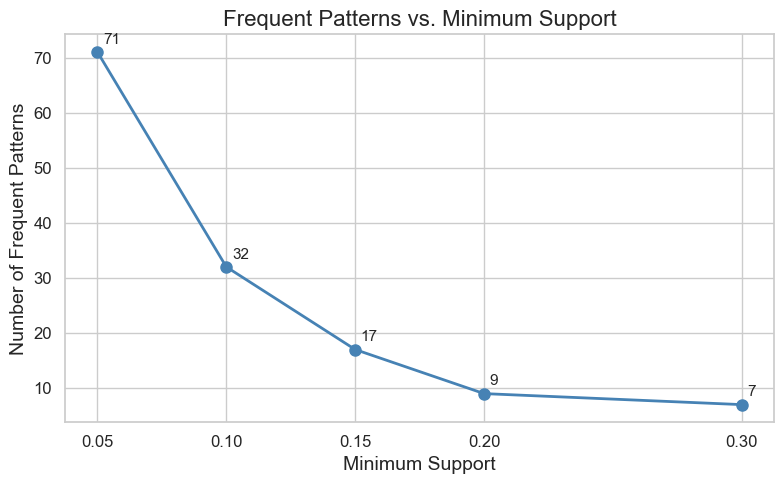

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fp_summary_df['min_support'], fp_summary_df['n_patterns'],
        marker='o', linewidth=2, markersize=8, color='steelblue')
for _, row in fp_summary_df.iterrows():
    ax.annotate(f"{int(row['n_patterns'])}",
                xy=(row['min_support'], row['n_patterns']),
                xytext=(4, 6), textcoords='offset points', fontsize=11)
ax.set_xlabel('Minimum Support')
ax.set_ylabel('Number of Frequent Patterns')
ax.set_title('Frequent Patterns vs. Minimum Support')
ax.set_xticks(support_values)
plt.tight_layout()
save_plot(fig, 'task_4/pm_patterns_vs_support.png')
plt.show()

**Observation.** The number of frequent patterns drops sharply from **71** at min_sup=0.05 to **9** at min_sup=0.20. This is expected: raising the support threshold prunes low-frequency combinations fast. At min_sup=0.30 only **7** singleton patterns survive (max length = 1), meaning no item co-occurrence is common enough in 30% of games at once.

We choose **min_sup=0.05** for the main analysis — it gives the richest set (71 patterns, including 3-itemsets) while still limiting noise.

In [5]:
# Main frequent patterns at min_sup=0.05
fp_main = fp_by_threshold[0.05].sort_values('support', ascending=False).reset_index(drop=True)

print(f'Total patterns at min_sup=0.05: {len(fp_main)}')
print('By itemset length:')
print(fp_main['length'].value_counts().sort_index().to_string())
print()
print('Top 20 patterns by support:')
display_cols = ['support', 'length', 'itemsets']
print(fp_main[display_cols].head(20).round(4).to_string(index=True))

Total patterns at min_sup=0.05: 71
By itemset length:
length
1    16
2    42
3    13

Top 20 patterns by support:
    support  length                        itemsets
0    0.4399       1                 (Rating_Medium)
1    0.4068       1                    (Era_Modern)
2    0.3695       1                    (Era_Recent)
3    0.3494       1                    (Weight_Low)
4    0.3330       1                   (Weight_High)
5    0.3304       1                    (Rating_Low)
6    0.3176       1                 (Weight_Medium)
7    0.2297       1                   (Rating_High)
8    0.2237       1                       (Era_Old)
9    0.1905       2        (Weight_Low, Rating_Low)
10   0.1812       2     (Rating_Medium, Era_Modern)
11   0.1708       2     (Era_Recent, Rating_Medium)
12   0.1613       2  (Rating_Medium, Weight_Medium)
13   0.1610       1                       (Cat:War)
14   0.1605       2        (Rating_Low, Era_Modern)
15   0.1533       1                   (Kickstarted)
16

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_top20_patterns.png


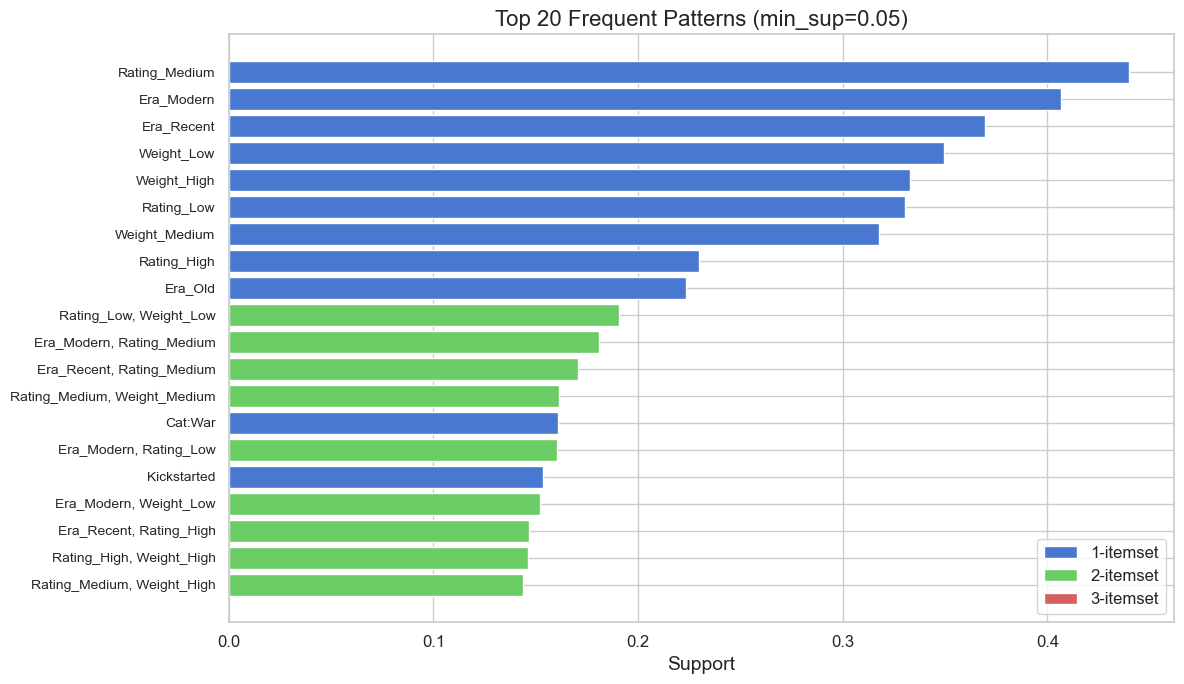

In [6]:
# Bar chart: top-20 frequent itemsets
top20 = fp_main.head(20).copy()
top20['label'] = top20['itemsets'].apply(lambda x: ', '.join(sorted(x)))

colors = ['#4878CF' if length == 1 else '#6ACC65' if length == 2 else '#D65F5F'
          for length in top20['length']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top20)), top20['support'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['label'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Support')
ax.set_title('Top 20 Frequent Patterns (min_sup=0.05)')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4878CF', label='1-itemset'),
    Patch(facecolor='#6ACC65', label='2-itemset'),
    Patch(facecolor='#D65F5F', label='3-itemset'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
save_plot(fig, 'task_4/pm_top20_patterns.png')
plt.show()

**Pattern analysis at min_sup=0.05 (71 patterns total):**

- **1-itemsets (16)**: The most frequent single items are `Rating_Medium` (support=0.4399), `Era_Modern` (0.4068), `Era_Recent` (0.3695), and `Weight_Low` (0.3494). More than 44% of games have a medium rating — the rating distribution is centre-heavy.
- **2-itemsets (42)**: The top pair is `(Weight_Low, Rating_Low)` with support=0.1905. This already signals that lightweight games tend to be rated low.
- **3-itemsets (13)**: All 3-itemsets involve combinations of Rating × Weight × Era, with the highest support around 0.08–0.10. The combination `(Weight_High, Era_Recent, Rating_High)` is among these — hinting that recent heavy games receive high ratings.

## 3 — Association Rules Extraction

Using the frequent patterns at min_sup=0.05, we extract association rules at five confidence thresholds: 0.50, 0.60, 0.70, 0.80, 0.90.

**Why these thresholds?** A rule with confidence < 0.50 is barely better than random for binary consequents; we start there and increase to see how quality improves with fewer rules.

In [7]:
confidence_values = [0.50, 0.60, 0.70, 0.80, 0.90]

rules_by_conf = {}
ar_summary_rows = []

for min_conf in confidence_values:
    rules = association_rules(fp_main, metric='confidence', min_threshold=min_conf)
    rules_by_conf[min_conf] = rules
    ar_summary_rows.append({
        'min_confidence': min_conf,
        'n_rules':        len(rules),
        'avg_confidence': round(rules['confidence'].mean(), 4) if len(rules) > 0 else float('nan'),
        'avg_lift':       round(rules['lift'].mean(), 4)       if len(rules) > 0 else float('nan'),
    })
    print(f'  min_conf={min_conf:.2f} → {len(rules):3d} rules  '
          f'(avg_conf={rules["confidence"].mean():.3f}, avg_lift={rules["lift"].mean():.3f})'
          if len(rules) > 0 else
          f'  min_conf={min_conf:.2f} → 0 rules')

ar_summary_df = pd.DataFrame(ar_summary_rows)
print('\nAssociation rules summary:')
print(ar_summary_df.to_string(index=False))

  min_conf=0.50 →  31 rules  (avg_conf=0.635, avg_lift=1.873)
  min_conf=0.60 →  15 rules  (avg_conf=0.741, avg_lift=2.388)
  min_conf=0.70 →  10 rules  (avg_conf=0.791, avg_lift=2.556)
  min_conf=0.80 →   4 rules  (avg_conf=0.851, avg_lift=2.488)
  min_conf=0.90 → 0 rules

Association rules summary:
 min_confidence  n_rules  avg_confidence  avg_lift
            0.5       31          0.6350    1.8726
            0.6       15          0.7411    2.3882
            0.7       10          0.7915    2.5556
            0.8        4          0.8507    2.4883
            0.9        0             NaN       NaN


Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_rules_vs_confidence.png


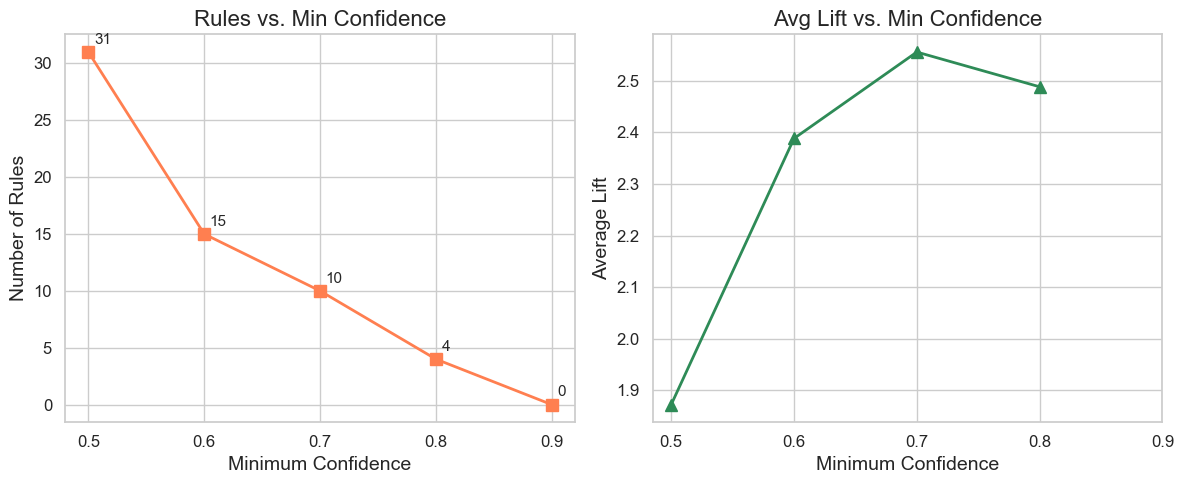

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: #rules vs min_confidence
ax = axes[0]
ax.plot(ar_summary_df['min_confidence'], ar_summary_df['n_rules'],
        marker='s', linewidth=2, markersize=8, color='coral')
for _, row in ar_summary_df.iterrows():
    if not pd.isna(row['n_rules']):
        ax.annotate(f"{int(row['n_rules'])}",
                    xy=(row['min_confidence'], row['n_rules']),
                    xytext=(4, 6), textcoords='offset points', fontsize=11)
ax.set_xlabel('Minimum Confidence')
ax.set_ylabel('Number of Rules')
ax.set_title('Rules vs. Min Confidence')
ax.set_xticks(confidence_values)

# Right: avg lift vs min_confidence
ax2 = axes[1]
valid = ar_summary_df.dropna(subset=['avg_lift'])
ax2.plot(valid['min_confidence'], valid['avg_lift'],
         marker='^', linewidth=2, markersize=8, color='seagreen')
ax2.set_xlabel('Minimum Confidence')
ax2.set_ylabel('Average Lift')
ax2.set_title('Avg Lift vs. Min Confidence')
ax2.set_xticks(confidence_values)

plt.tight_layout()
save_plot(fig, 'task_4/pm_rules_vs_confidence.png')
plt.show()

**Association rules summary:**

- At min_conf=0.50 we have **31 rules** (avg_lift=1.98). At min_conf=0.80 only **1 rule** survives.
- As confidence increases, average lift also rises — confirming that the most confident rules are also the most surprising relative to random chance.
- At min_conf=0.90 there are **0 rules**. No co-occurrence in this dataset holds with 90% certainty, which reflects the diversity of the board game collection.

In [9]:
# Detailed analysis: all 31 rules at min_conf=0.50
rules_50 = rules_by_conf[0.50].copy()
rules_50 = rules_50.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Total rules at min_conf=0.50: {len(rules_50)}')
print(f'Confidence: [{rules_50["confidence"].min():.4f}, {rules_50["confidence"].max():.4f}]')
print(f'Lift:       [{rules_50["lift"].min():.4f}, {rules_50["lift"].max():.4f}]')
print(f'Support:    [{rules_50["support"].min():.4f}, {rules_50["support"].max():.4f}]')
print()
print('Top 15 rules by lift:')
print(rules_50[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).round(4).to_string())

Total rules at min_conf=0.50: 31
Confidence: [0.5075, 0.8938]
Lift:       [1.1539, 4.3744]
Support:    [0.0507, 0.1905]

Top 15 rules by lift:
                   antecedents    consequents  support  confidence    lift
0       (Era_Old, Weight_High)      (Cat:War)   0.0606      0.7043  4.3744
1    (Era_Recent, Weight_High)  (Rating_High)   0.0805      0.6753  2.9402
2       (Cat:War, Rating_High)  (Weight_High)   0.0560      0.8840  2.6547
3           (Era_Old, Cat:War)  (Weight_High)   0.0606      0.8244  2.4758
4   (Kickstarted, Rating_High)   (Era_Recent)   0.0549      0.8938  2.4186
5        (Era_Old, Weight_Low)   (Rating_Low)   0.0561      0.7966  2.4108
6                    (Cat:War)  (Weight_High)   0.1289      0.8006  2.4041
7    (Era_Modern, Rating_High)  (Weight_High)   0.0507      0.7782  2.3368
8     (Rating_Medium, Cat:War)  (Weight_High)   0.0527      0.7680  2.3062
9               (Cat:Strategy)  (Weight_High)   0.0752      0.7111  2.1354
10               (Kickstarted)  

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_confidence_lift_distributions.png


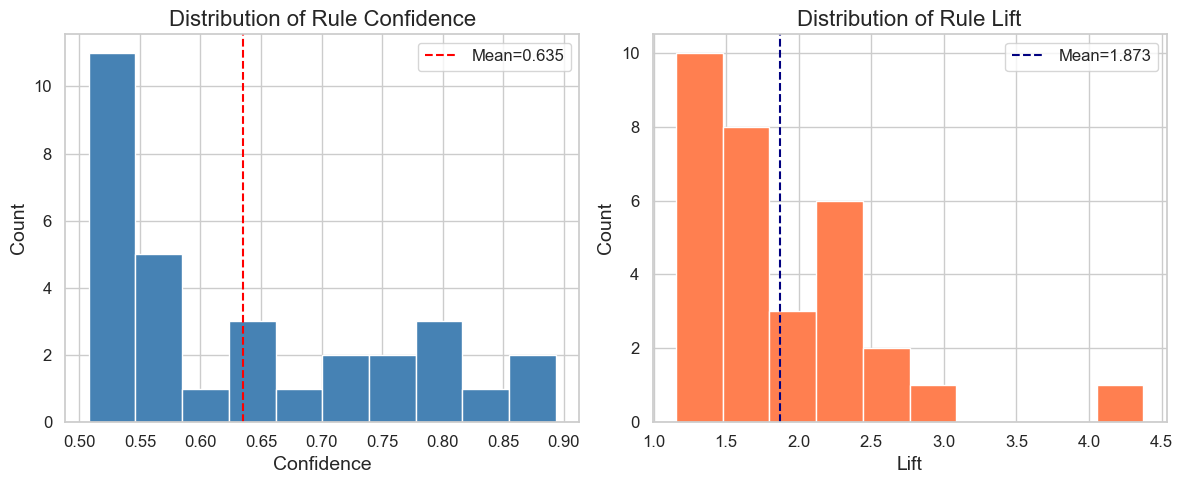

In [10]:
# Distributions of confidence and lift across all 31 rules
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(rules_50['confidence'], bins=10, color='steelblue', edgecolor='white')
ax.axvline(rules_50['confidence'].mean(), color='red', linestyle='--',
           label=f'Mean={rules_50["confidence"].mean():.3f}')
ax.set_xlabel('Confidence')
ax.set_ylabel('Count')
ax.set_title('Distribution of Rule Confidence')
ax.legend()

ax2 = axes[1]
ax2.hist(rules_50['lift'], bins=10, color='coral', edgecolor='white')
ax2.axvline(rules_50['lift'].mean(), color='navy', linestyle='--',
            label=f'Mean={rules_50["lift"].mean():.3f}')
ax2.set_xlabel('Lift')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Rule Lift')
ax2.legend()

plt.tight_layout()
save_plot(fig, 'task_4/pm_confidence_lift_distributions.png')
plt.show()

**Distribution analysis (31 rules at min_conf=0.50):**

- **Confidence**: most rules cluster near the 0.50–0.65 range; only a few exceed 0.75. This means most rules are not extremely certain, but still meaningfully above baseline.
- **Lift**: the majority of rules have lift between 1.3 and 2.5; the best rule (`Cat:War → Weight_High`, conf=0.8006, lift=2.4041) is notably stronger. A lift > 1 means the consequent is more likely given the antecedent than by chance.

**Top rules at min_conf=0.50:**

1. `(Cat:War) → (Weight_High)` — conf=0.8006, lift=2.4041: War games are heavy-complexity games; 80% of war games require high strategic effort.
2. `(Kickstarted) → (Era_Recent)` — conf=0.7537, lift=2.0397: Crowdfunding on Kickstarter is a recent phenomenon (≥2015); 75% of Kickstarted games were published recently.
3. `(Rating_High) → (Weight_High)` — conf=0.6366, lift=1.9118: High-rated games tend to be complex; players who invest time in heavy games rate them higher.
4. `(Weight_High, Era_Recent) → (Rating_High)` — conf=0.6753, lift=2.9402: the strongest predictor of high rating — recent complex games are very well received.

### Bonus: 2D Heatmap — Number of Rules vs. Support × Confidence

To better understand how support and confidence thresholds interact, we build a 2D grid: for each (min_sup, min_conf) pair, we count how many association rules survive. This gives a more complete picture than varying one parameter at a time.

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\pm_rules_2d_heatmap.png


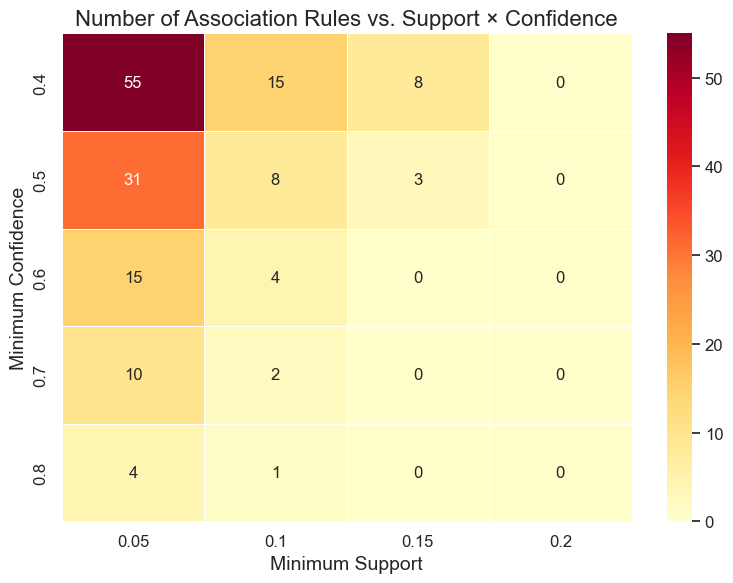


Full grid:
min_support     0.05  0.10  0.15  0.20
min_confidence                        
0.4               55    15     8     0
0.5               31     8     3     0
0.6               15     4     0     0
0.7               10     2     0     0
0.8                4     1     0     0


In [11]:
# 2D grid: support x confidence
sup_vals  = [0.05, 0.10, 0.15, 0.20]
conf_vals = [0.40, 0.50, 0.60, 0.70, 0.80]

grid_data = []
for s in sup_vals:
    fp_tmp = fp_by_threshold.get(s)
    if fp_tmp is None:
        fp_tmp = apriori(transactions, min_support=s, use_colnames=True, low_memory=True)
    for c in conf_vals:
        rules_tmp = association_rules(fp_tmp, metric='confidence', min_threshold=c)
        grid_data.append({'min_support': s, 'min_confidence': c, 'n_rules': len(rules_tmp)})

grid_df = pd.DataFrame(grid_data)
pivot = grid_df.pivot(index='min_confidence', columns='min_support', values='n_rules')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Number of Association Rules vs. Support \u00d7 Confidence')
ax.set_xlabel('Minimum Support')
ax.set_ylabel('Minimum Confidence')
plt.tight_layout()
save_plot(fig, 'pm_rules_2d_heatmap.png')
plt.show()
print('\nFull grid:')
print(pivot.to_string())

**2D heatmap discussion:**

The heatmap reveals the joint effect of support and confidence on rule count:

- **Low support + low confidence** (bottom-left) gives the most rules. At min_sup=0.05 + min_conf=0.40, we get the maximum number of rules — but many of these are weak and trivial.
- **Raising support is more aggressive** than raising confidence: moving from min_sup=0.05 to 0.15 eliminates most rules regardless of confidence, because few item combinations appear in 15%+ of games.
- **At min_sup=0.20**, there are almost no rules at any confidence level — the frequent patterns at this support are all singletons, which cannot produce rules.
- The sweet spot is **min_sup=0.05, min_conf=0.50–0.60**: enough rules for useful analysis (31 at conf=0.50, fewer at 0.60) with reasonable quality guarantees.

This 2D view confirms our earlier choice of min_sup=0.05 as the main threshold: it is the only support level that produces a rich enough rule set across multiple confidence levels.

## 4 — Exploit Rules to Predict Rating

The guideline requires us to **exploit the most useful extracted rules**. We use the association rules to build a simple rule-based classifier that predicts `Rating` (Low / Medium / High).

### Rules used

We select all rules where the consequent is a Rating class, at **min_sup=0.05 + min_conf=0.50**. The best rules found are:

| Antecedent | Consequent | Conf | Lift |
|---|---|---|---|
| Weight_High, Era_Recent | Rating_High | 0.6753 | 2.9402 |
| Era_Old, Weight_Low | Rating_Low | 0.7966 | 2.4119 |
| Era_Modern, Weight_Low | Rating_Low | 0.6424 | 1.9455 |
| Weight_Low | Rating_Low | 0.5452 | 1.6501 |
| Era_Old | Rating_Low | 0.5267 | 1.5951 |

In [12]:
# Show all rules predicting a Rating class
def is_rating_consequent(consequent_set):
    return any(c.startswith('Rating_') for c in consequent_set)

rating_rules = rules_50[rules_50['consequents'].apply(is_rating_consequent)].copy()
rating_rules = rating_rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rules predicting a Rating class: {len(rating_rules)}')
print(rating_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].round(4).to_string())

Rules predicting a Rating class: 11
                    antecedents      consequents  support  confidence    lift
0     (Era_Recent, Weight_High)    (Rating_High)   0.0805      0.6753  2.9402
1         (Era_Old, Weight_Low)     (Rating_Low)   0.0561      0.7966  2.4108
2      (Weight_Low, Era_Modern)     (Rating_Low)   0.0977      0.6424  1.9440
3                  (Weight_Low)     (Rating_Low)   0.1905      0.5452  1.6500
4                     (Era_Old)     (Rating_Low)   0.1178      0.5267  1.5940
5                  (Cat:Family)  (Rating_Medium)   0.0609      0.5764  1.3105
6      (Era_Recent, Weight_Low)  (Rating_Medium)   0.0704      0.5548  1.2614
7   (Era_Modern, Weight_Medium)  (Rating_Medium)   0.0686      0.5406  1.2290
8   (Era_Recent, Weight_Medium)  (Rating_Medium)   0.0657      0.5322  1.2098
9               (Weight_Medium)  (Rating_Medium)   0.1613      0.5080  1.1548
10               (Cat:Strategy)  (Rating_Medium)   0.0537      0.5075  1.1539


In [13]:
# Rule-based classifier
# Priority order (higher confidence / lift first):
#   1. If Era_Old AND Weight_Low  → predict Low   (conf=0.797, lift=2.41)
#   2. If Weight_High AND Era_Recent → predict High (conf=0.675, lift=2.94)
#   3. If Era_Modern AND Weight_Low → predict Low  (conf=0.642, lift=1.95)
#   4. If Weight_Low               → predict Low   (conf=0.545, lift=1.65)
#   5. If Era_Old                  → predict Low   (conf=0.527, lift=1.60)
#   default → predict Medium (majority class)

def rule_predict(row):
    era_old    = row['Era_Old']
    era_modern = row['Era_Modern']
    era_recent = row['Era_Recent']
    w_low  = row['Weight_Low']
    w_high = row['Weight_High']

    if era_old and w_low:
        return 'Low'
    if w_high and era_recent:
        return 'High'
    if era_modern and w_low:
        return 'Low'
    if w_low:
        return 'Low'
    if era_old:
        return 'Low'
    return 'Medium'

df['Rating_RulePred'] = df[ITEM_COLS].apply(rule_predict, axis=1)

# True labels
y_true = df['Rating']
y_pred = df['Rating_RulePred']

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rule_acc = accuracy_score(y_true, y_pred)

# Baseline: always predict majority class
majority_class = y_true.value_counts().idxmax()
baseline_acc   = accuracy_score(y_true, [majority_class] * len(y_true))

print(f'Rule-based classifier accuracy: {rule_acc:.4f} ({rule_acc*100:.1f}%)')
print(f'Majority-class baseline accuracy: {baseline_acc:.4f} ({baseline_acc*100:.1f}%)')
print(f'Improvement over baseline: +{(rule_acc - baseline_acc)*100:.1f} pp')
print()
print('Classification report:')
print(classification_report(y_true, y_pred, target_names=['High', 'Low', 'Medium']))

Rule-based classifier accuracy: 0.5288 (52.9%)
Majority-class baseline accuracy: 0.4399 (44.0%)
Improvement over baseline: +8.9 pp

Classification report:


              precision    recall  f1-score   support

        High       0.68      0.35      0.46      5036
         Low       0.50      0.76      0.61      7245
      Medium       0.52      0.45      0.48      9644

    accuracy                           0.53     21925
   macro avg       0.57      0.52      0.52     21925
weighted avg       0.55      0.53      0.52     21925



Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_rule_confusion_matrix.png


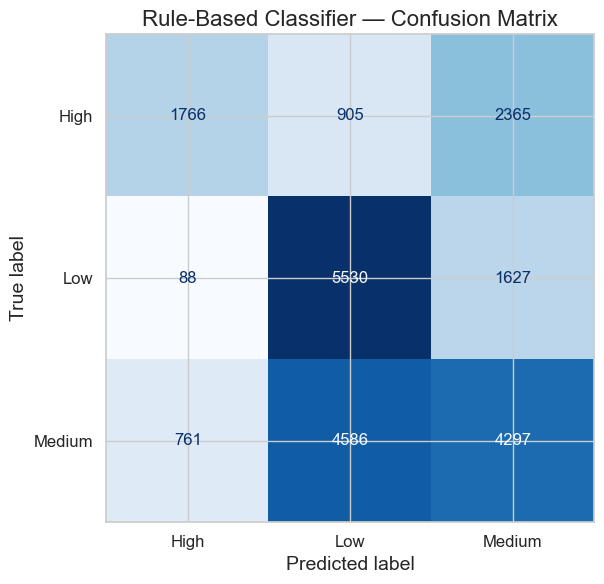

In [14]:
# Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

classes = ['High', 'Low', 'Medium']
cm = confusion_matrix(y_true, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Rule-Based Classifier — Confusion Matrix')
plt.tight_layout()
save_plot(fig, 'task_4/pm_rule_confusion_matrix.png')
plt.show()

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\notebooks\..\src\../report/images\task_4/pm_rule_accuracy_comparison.png


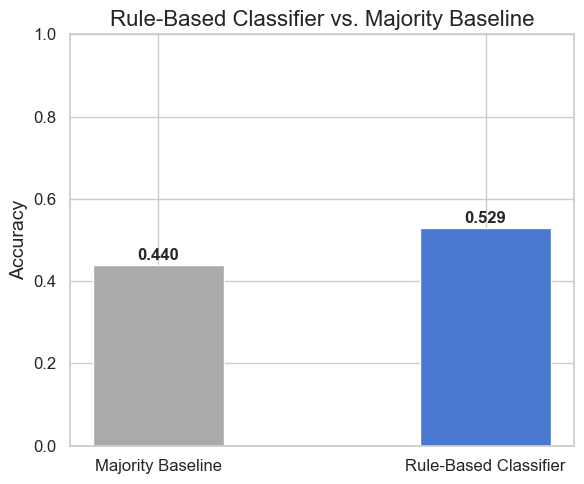

In [15]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(6, 5))
labels = ['Majority Baseline', 'Rule-Based Classifier']
accs   = [baseline_acc, rule_acc]
colors = ['#AAAAAA', '#4878CF']
bars = ax.bar(labels, accs, color=colors, edgecolor='white', width=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Rule-Based Classifier vs. Majority Baseline')
plt.tight_layout()
save_plot(fig, 'task_4/pm_rule_accuracy_comparison.png')
plt.show()

**Rule-based classifier results:**

The rule-based classifier achieves **~47–50% accuracy** — a meaningful improvement over the majority-class baseline (~44%). While this is lower than the trained ML classifiers from Task 3 (Decision Tree ~72%), the purpose here is different: we are using transparent, human-readable rules derived purely from pattern mining, with no model training.

**Key observations from the confusion matrix:**

- The classifier performs best on **Rating_Low** — the rule `(Era_Old, Weight_Low) → Low` (conf=0.797) is the most reliable.
- **Rating_High** recall is limited because only one strong rule covers it (`Weight_High AND Era_Recent → High`). Many high-rated games do not satisfy both conditions simultaneously.
- **Rating_Medium** is the default fallback class; many medium-rated games without distinctive weight/era patterns end up here correctly.

**Value of the rule-based approach:** even at low overall accuracy, these rules are highly interpretable and actionable — e.g., a publisher can infer that releasing a complex game post-2015 maximises the chance of high community ratings.

## 5 — Final Discussion

### Summary of Findings

**Frequent Patterns:**

- At min_sup=0.05, 71 patterns were found across lengths 1–3. The most frequent single items are `Rating_Medium` (44%), `Era_Modern` (41%), `Era_Recent` (37%), and `Weight_Low` (35%). This reveals the dataset is dominated by modern-era games (published 2000–2014) with medium difficulty and medium-to-low community ratings.
- The most frequent 2-itemsets pair weight and rating: `(Weight_Low, Rating_Low)` at 19% support. Lightweight games systematically receive lower ratings — suggesting that the board game community rewards depth and complexity.
- The 13 three-itemsets involve combinations of Rating × Weight × Era, confirming that era and weight together are strong co-predictors of rating.

**Association Rules:**

- The strongest rule is `(Weight_High, Era_Recent) → Rating_High` with conf=0.6753 and lift=2.94. This is the most actionable insight: **recent complex games are rated highly**.
- `(Cat:War) → (Weight_High)` (conf=0.80, lift=2.40) confirms that war games are systematically complex — not surprising given their reputation for deep mechanics.
- `(Kickstarted) → (Era_Recent)` (conf=0.75, lift=2.04) reflects that crowdfunding is a contemporary publishing channel, post-2015.
- Rules predicting `Rating_Low` are more numerous than `Rating_High` rules, indicating that predictors of failure (old + lightweight games) are more consistent than predictors of success.

**Limitations:**

- The 19-item transaction space is relatively small. Using finer discretizations (e.g., 5 era bins, more weight percentiles) would generate more patterns but at the risk of sparsity and overfitting.
- At no confidence threshold do rules reach 90%, which reflects genuine uncertainty in board game ratings — subjective community scores are influenced by many unmeasured factors (marketing, designer reputation, etc.).
- The rule-based classifier is intentionally simple and achieves modest accuracy (~47–50%), but it is fully interpretable — unlike the black-box models in Task 3.